In [25]:
import pandas as pd

def clean_retail_data(file_path):
    print(f"Loading dataset from {file_path}...")
    df = pd.read_csv(file_path)

    # 1. Convert InvoiceDate to datetime
    print("Converting dates...")
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    # 2. Handle missing values
    initial_rows = len(df)
    df.dropna(subset=['Customer ID'], inplace=True)
    print(f"Dropped {initial_rows - len(df)} rows missing a Customer ID.")

    # 3. Remove cancelled orders
    # Convert Invoice to string to check for 'C' (cancellations)
    df['Invoice'] = df['Invoice'].astype(str)
    df = df[~df['Invoice'].str.startswith('C')]
    df = df[df['Quantity'] > 0]

    # 4. Create TotalAmount feature
    df['TotalAmount'] = df['Quantity'] * df['Price']

    print("\n--- Final Cleaned Data Info ---")
    print(df.info())

    return df

# Run the pipeline
cleaned_df = clean_retail_data('online_retail_II.csv')

# Save the cleaned data for Prompt 2
cleaned_df.to_csv('cleaned_retail_data.csv', index=False)
print("\nSuccess! Cleaned data saved as 'cleaned_retail_data.csv'.")

Loading dataset from online_retail_II.csv...
Converting dates...
Dropped 243007 rows missing a Customer ID.

--- Final Cleaned Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[ns]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  object        
 8   TotalAmount  805620 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 61.5+ MB
None

Success! Cleaned data saved as 'cleaned_retail_data.csv'.


Loading cleaned data...
Calculating RFM metrics...
Scaling data for K-Means...
Applying K-Means Clustering (k=4)...

--- Cluster Averages ---
            Recency   Frequency       Monetary
Cluster                                       
0         66.991931    7.306351    3008.619160
1        463.234000    2.211000     764.479201
2         25.942857  103.742857   83086.079771
3          3.500000  212.750000  436835.792500

Generating visualization...
Saved visualization as 'segmentation_plot.png'.
Success! RFM clustered data saved as 'rfm_segments.csv'.


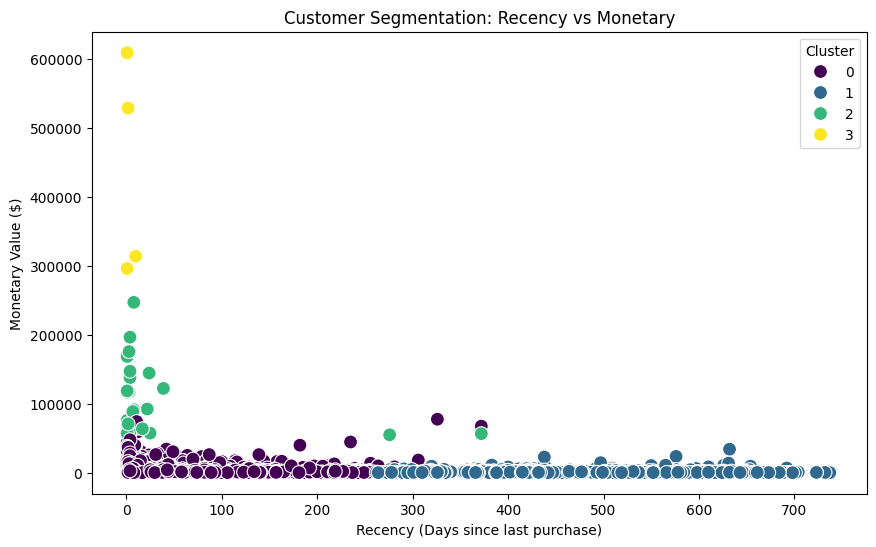

In [26]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

def segment_customers(file_path):
    print("Loading cleaned data...")
    df = pd.read_csv(file_path)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    # 1. Calculate RFM
    print("Calculating RFM metrics...")
    # Simulate a 'today' for Recency calculation (using latest date in data + 1 day)
    snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

    rfm = df.groupby('Customer ID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: days since last purchase
        'Invoice': 'nunique',                                     # Frequency: total distinct invoices
        'TotalAmount': 'sum'                                      # Monetary: total spend
    }).reset_index()

    rfm.rename(columns={'InvoiceDate': 'Recency',
                        'Invoice': 'Frequency',
                        'TotalAmount': 'Monetary'}, inplace=True)

    # 2. Scale the data
    print("Scaling data for K-Means...")
    scaler = StandardScaler()
    # K-Means is distance-based, so we must scale these highly varied numbers
    rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

    # 3. K-Means Clustering
    print("Applying K-Means Clustering (k=4)...")
    # We'll use 4 clusters to start (e.g., VIPs, Loyalists, At-Risk, Churned)
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

    print("\n--- Cluster Averages ---")
    print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean())

    # 4. Visualization
    print("\nGenerating visualization...")
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis', s=100)
    plt.title('Customer Segmentation: Recency vs Monetary')
    plt.xlabel('Recency (Days since last purchase)')
    plt.ylabel('Monetary Value ($)')

    # Save the plot for your Zidio PDF report
    plt.savefig('segmentation_plot.png')
    print("Saved visualization as 'segmentation_plot.png'.")

    return rfm

# Run the pipeline
rfm_df = segment_customers('cleaned_retail_data.csv')

# Save the final segmented data for the next phase
rfm_df.to_csv('rfm_segments.csv', index=False)
print("Success! RFM clustered data saved as 'rfm_segments.csv'.")

In [27]:
!pip install -q streamlit pandas matplotlib seaborn

In [28]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Page Configuration ---
st.set_page_config(page_title="RetailPulse Analytics", layout="wide")

# --- 2. Sidebar Navigation ---
st.sidebar.title("RetailPulse Navigation")
st.sidebar.markdown("End-to-End Retail Analytics")
page = st.sidebar.radio("Select Module:", [
    "Overview",
    "Customer Segmentation",
    "Demand Forecasting",
    "Inventory Optimization"
])

# --- 3. Data Loading (From Phase 1) ---
@st.cache_data
def load_segmentation_data():
    file_path = "rfm_segments.csv"
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    return None

rfm_df = load_segmentation_data()

# --- 4. Page Routing & Logic ---

if page == "Overview":
    st.title("RetailPulse: AI-Powered Analytics Platform")
    st.markdown("Welcome to the production dashboard. Use the sidebar to navigate the modules.")

    if rfm_df is not None:
        st.subheader("Current Business Metrics")
        col1, col2, col3 = st.columns(3)
        col1.metric("Total Active Customers", f"{len(rfm_df):,}")
        col2.metric("Total Revenue", f"${rfm_df['Monetary'].sum():,.2f}")
        col3.metric("Average Recency", f"{rfm_df['Recency'].mean():.0f} days")
    else:
        st.error("⚠️ 'rfm_segments.csv' not found. Please ensure Phase 1 data is uploaded to Colab.")

elif page == "Customer Segmentation":
    st.title("Customer Segmentation Insights")
    st.write("Visualizing behavioral clusters using RFM analysis and K-Means.")

    if rfm_df is not None:
        col1, col2 = st.columns([1, 2])
        with col1:
            st.dataframe(rfm_df[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster']].head(15))
        with col2:
            fig, ax = plt.subplots(figsize=(8, 5))
            sns.scatterplot(data=rfm_df, x='Recency', y='Monetary', hue='Cluster', palette='viridis', s=80, ax=ax)
            ax.set_title("Recency vs Monetary Value")
            st.pyplot(fig)
    else:
        st.error("⚠️ 'rfm_segments.csv' not found.")

elif page == "Demand Forecasting":
    st.title("Demand Forecasting")
    st.info("⏳ Phase 2 Data Required: The Prophet and LSTM models need to be trained before predictions can populate here.")

elif page == "Inventory Optimization":
    st.title("Inventory Optimization & What-If Analysis")

    st.markdown("### Adjust Supply Chain Parameters")
    col1, col2 = st.columns(2)
    with col1:
        lead_time = st.slider("Supplier Lead Time (Days)", 1, 30, 7)
    with col2:
        safety_stock_mult = st.slider("Safety Stock Multiplier", 1.0, 3.0, 1.5, 0.1)

    st.markdown("### Reorder Recommendations")
    # Simulated prediction data until Phase 2 is complete
    np.random.seed(42)
    simulated_products = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
    avg_daily_demand = np.random.randint(10, 100, size=5)
    std_dev_demand = np.random.randint(2, 15, size=5)

    safety_stock = np.ceil(std_dev_demand * lead_time * safety_stock_mult)
    reorder_point = np.ceil((avg_daily_demand * lead_time) + safety_stock)

    opt_df = pd.DataFrame({
        'Product': simulated_products,
        'Avg Daily Demand': avg_daily_demand,
        'Safety Stock Required': safety_stock,
        'Reorder Point': reorder_point
    })

    st.dataframe(opt_df, use_container_width=True)

    st.markdown("### Export Report")
    csv = opt_df.to_csv(index=False).encode('utf-8')
    st.download_button(
        label="Download Inventory Report as CSV",
        data=csv,
        file_name='inventory_optimization_report.csv',
        mime='text/csv',
    )

Overwriting app.py
